In [1]:
import numpy as np

def _unbroadcast(grad, shape):
    while grad.ndim > len(shape):
        grad = grad.sum(axis=0)
    for i, (g, s) in enumerate(zip(grad.shape, shape)):
        if s == 1 and g > 1:
            grad = grad.sum(axis=i, keepdims=True)
    return grad

class Tensor:
    def __init__(self, data):
        self.data = np.asarray(data, dtype=np.float64)
        self.grad = np.zeros_like(self.data)
        self._back = lambda: None
        self._children = []

    def __repr__(self):
        return str(self.data)

    def __add__(self, other):
        out = Tensor(self.data + other.data)
        def _back():
            self.grad  += _unbroadcast(out.grad, self.data.shape)
            other.grad += _unbroadcast(out.grad, other.data.shape)
        out._back = _back
        out._children = [self, other]
        return out

    def __mul__(self, other):
        out = Tensor(self.data * other.data)
        def _back():
            self.grad  += _unbroadcast(other.data * out.grad, self.data.shape)
            other.grad += _unbroadcast(self.data  * out.grad, other.data.shape)
        out._back = _back
        out._children = [self, other]
        return out

    def __sub__(self, other):
        return self + (Tensor([-1]) * other)

    def __matmul__(self, other):
        out = Tensor(self.data @ other.data)
        def _back():
            # grad w.r.t. self
            if self.data.ndim == 2 and other.data.ndim == 1:
                self.grad += np.outer(out.grad, other.data)
            else:
                self.grad += out.grad @ other.data.T

            # grad w.r.t. other
            if self.data.ndim == 1 and other.data.ndim == 2:
                other.grad += np.outer(self.data, out.grad)
            else:
                other.grad += self.data.T @ out.grad

        out._back = _back
        out._children = [self, other]
        return out

    def relu(self):
        out = Tensor(np.maximum(0, self.data))
        def _back():
            self.grad += (out.data > 0) * out.grad
        out._back = _back
        out._children = [self]
        return out

    def reshape(self, *shape):
        out = Tensor(self.data.reshape(*shape))
        def _back():
            self.grad += out.grad.reshape(self.data.shape)
        out._back = _back
        out._children = [self]
        return out

    def flatten(self, start_dim=0):
        shape = self.data.shape
        new_shape = shape[:start_dim] + (-1,)
        return self.reshape(*new_shape)

    def __getitem__(self, idx):
        orig_shape = self.data.shape
        out = Tensor(self.data[idx])
        def _back():
            grad = np.zeros(orig_shape, dtype=self.data.dtype)
            grad[idx] += out.grad
            self.grad += grad
        out._back = _back
        out._children = [self]
        return out

    def exp(self):
        out = Tensor(np.exp(self.data))
        def _back():
            self.grad += out.data * out.grad
        out._back = _back
        out._children = [self]
        return out

    def log(self):
        out = Tensor(np.log(self.data))
        def _back():
            self.grad += (1.0 / self.data) * out.grad
        out._back = _back
        out._children = [self]
        return out

    def sum(self, axis=None, keepdims=False):
        out = Tensor(self.data.sum(axis=axis, keepdims=keepdims))
        def _back():
            grad = out.grad
            if axis is not None and not keepdims:
                grad = np.expand_dims(grad, axis)
            self.grad += np.broadcast_to(grad, self.data.shape)
        out._back = _back
        out._children = [self]
        return out

    # def mean(self):
    #     n = self.data.size
    #     out = Tensor(self.data.mean())
    #     def _back():
    #         grad = out.grad * (1/n)
    #         self.grad += np.broadcast_to(grad, self.data.shape)
    #     out._back = _back
    #     return out

    def _topo_sort(self):
        topo = []
        def visit(v):
            if v not in topo:
                for child in v._children:
                    visit(child)
                topo.append(v)
        visit(self)
        return topo

    def backward(self):
        self.grad = np.ones_like(self.data)
        for v in reversed(self._topo_sort()):
            v._back()

class Linear:
    def __init__(self, in_features: int, out_features: int):
        self.W = Tensor(np.random.randn(in_features, out_features)*0.01)
        self.b = Tensor(np.zeros((1, out_features)))

    def __call__(self, x: Tensor) -> Tensor:
        return x @ self.W + self.b

    def parameters(self) -> list:
        return [self.W, self.b]

class Flatten:
    def __call__(self, x: Tensor) -> Tensor:
        return x.flatten()

        
class Kernel:
    def __init__(self, kernel_size: int):
        self.kernel_size = kernel_size

        # # Keeping kernel flat so we can use @
        self.W = Tensor(np.random.randn(kernel_size*kernel_size, 1)*0.01)
        self.b = Tensor(np.zeros((1, 1)))

    def apply(self, x: Tensor) -> Tensor:
        flat_x = x.flatten()
        return flat_x @ self.W + self.b

    def parameters(self) -> list:
        return [self.W, self.b]

class Conv2D:
    def __init__(self, kernel_count: int, kernel_size: int):
        self.kernel_count = kernel_count
        self.kernel_size = kernel_size
        self.kernels = [Kernel(kernel_size) for _ in range(kernel_count)]

    def __call__(self, x: Tensor) -> Tensor:
        output_size_x = x.data.shape[0] - self.kernel_size + 1
        output_size_y = x.data.shape[1] - self.kernel_size + 1

        out = Tensor(np.zeros((output_size_x, output_size_y, self.kernel_count)))
        out_backs = []

        # We will assume the input image is 2D for now as well.
        for i in range(output_size_x):
            for j in range(output_size_y):
                image_slice = x[i:i+self.kernel_size, j:j+self.kernel_size]
                for k, kernel in enumerate(self.kernels):
                    y = kernel.apply(image_slice)
                    out_backs.append(y._back)
                    out.data[i, j, k] += y.data

        def _back():
            for back in out_backs:
                back()

        out._back = _back
        return out

    def parameters(self) -> list:
        params = []
        for kernel in self.kernels:
            params.extend(kernel.parameters())
        return params

class ReLU:
    def __call__(self, x): return x.relu()

class Sequential:
    def __init__(self, *layers):
        self.layers = layers

    def __call__(self, x: Tensor) -> Tensor:
        for layer in self.layers:
            x = layer(x)
            # print("layer ", type(layer), " outputted ", x)
        return x

    def parameters(self) -> list:
        params = []
        for layer in self.layers:
            if hasattr(layer, 'parameters'):
                params.extend(layer.parameters())
        return params

def cross_entropy(logits: Tensor, target: int) -> Tensor:
    """
    logits: Tensor of shape (C,) — raw scores for one sample
    target: int — true class index
    """
    exps = logits.exp()          # exp(x_i) for each class
    sum_exps = exps.sum()        # sum_i exp(x_i)
    log_sum_exps = sum_exps.log()  # log(sum_i exp(x_i))
    logit_target = logits[target]  # x_target

    # cross entropy = log(sum(exp(x))) - x_target
    #   (this is algebraically -log(softmax(x)_target))
    loss = log_sum_exps - logit_target
    return loss

In [4]:
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

reshaped_data = digits.data.reshape(1797, 8, 8)

X = Tensor(reshaped_data)
Y = Tensor(digits.target) 


model = Sequential(
    Conv2D(3, 3),
    Flatten(),
    Linear(108, 10),
    ReLU(),
    Linear(10, 10),
    Flatten()
)

ce_log = []

for epoch in range(1, 25):
        ces = np.array([])
        for x, y in zip(X.data, Y.data):
            inp    = Tensor(x)
            target = Tensor([[y]])
            pred   = model(inp)
            ce = cross_entropy(pred, int(y))

            # Clear gradients from previous epoch.
            model_params = model.parameters()
            for p in model_params:
                p.grad = np.zeros_like(p.data)

            # Calculate new gradients.
            ce.backward()

            # Update weights.
            for p in model_params:
                p.data -= 0.05 * p.grad

            ces = np.append(ces, ce.data)


        ce_mean = ces.mean()
        ce_log.append(ce_mean)
    
        if epoch % 1 == 0:
            print(f"epoch {epoch:4d} | loss {ce_mean:.4f}")


/var/folders/s6/q45ssfhd6zv78kc74k09dv180000gn/T/ipykernel_20412/3758368364.py:195: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  out.data[i, j, k] += y.data


epoch    1 | loss 1.2826
epoch    2 | loss 0.2299
epoch    3 | loss 0.1475
epoch    4 | loss 0.1159
epoch    5 | loss 0.0965
epoch    6 | loss 0.0819
epoch    7 | loss 0.0714
epoch    8 | loss 0.0607
epoch    9 | loss 0.0533
epoch   10 | loss 0.0468
epoch   11 | loss 0.0406
epoch   12 | loss 0.0353
epoch   13 | loss 0.0316
epoch   14 | loss 0.0286
epoch   15 | loss 0.0260
epoch   16 | loss 0.0238
epoch   17 | loss 0.0213
epoch   18 | loss 0.0189
epoch   19 | loss 0.0173
epoch   20 | loss 0.0146
epoch   21 | loss 0.0128
epoch   22 | loss 0.0124
epoch   23 | loss 0.0113
epoch   24 | loss 0.0096


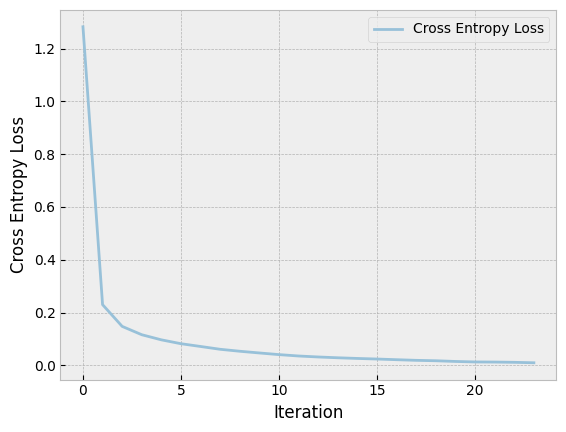

In [7]:
import matplotlib.pyplot as plt

plt.style.use('bmh') 
colors = ["#3d5a80","#98c1d9","#e0fbfc","#ee6c4d","#293241"]

plt.plot(ce_log, c=colors[1], label="Cross Entropy Loss")
plt.xlabel('Iteration')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.savefig("plot.png")

/var/folders/s6/q45ssfhd6zv78kc74k09dv180000gn/T/ipykernel_20412/3758368364.py:195: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  out.data[i, j, k] += y.data


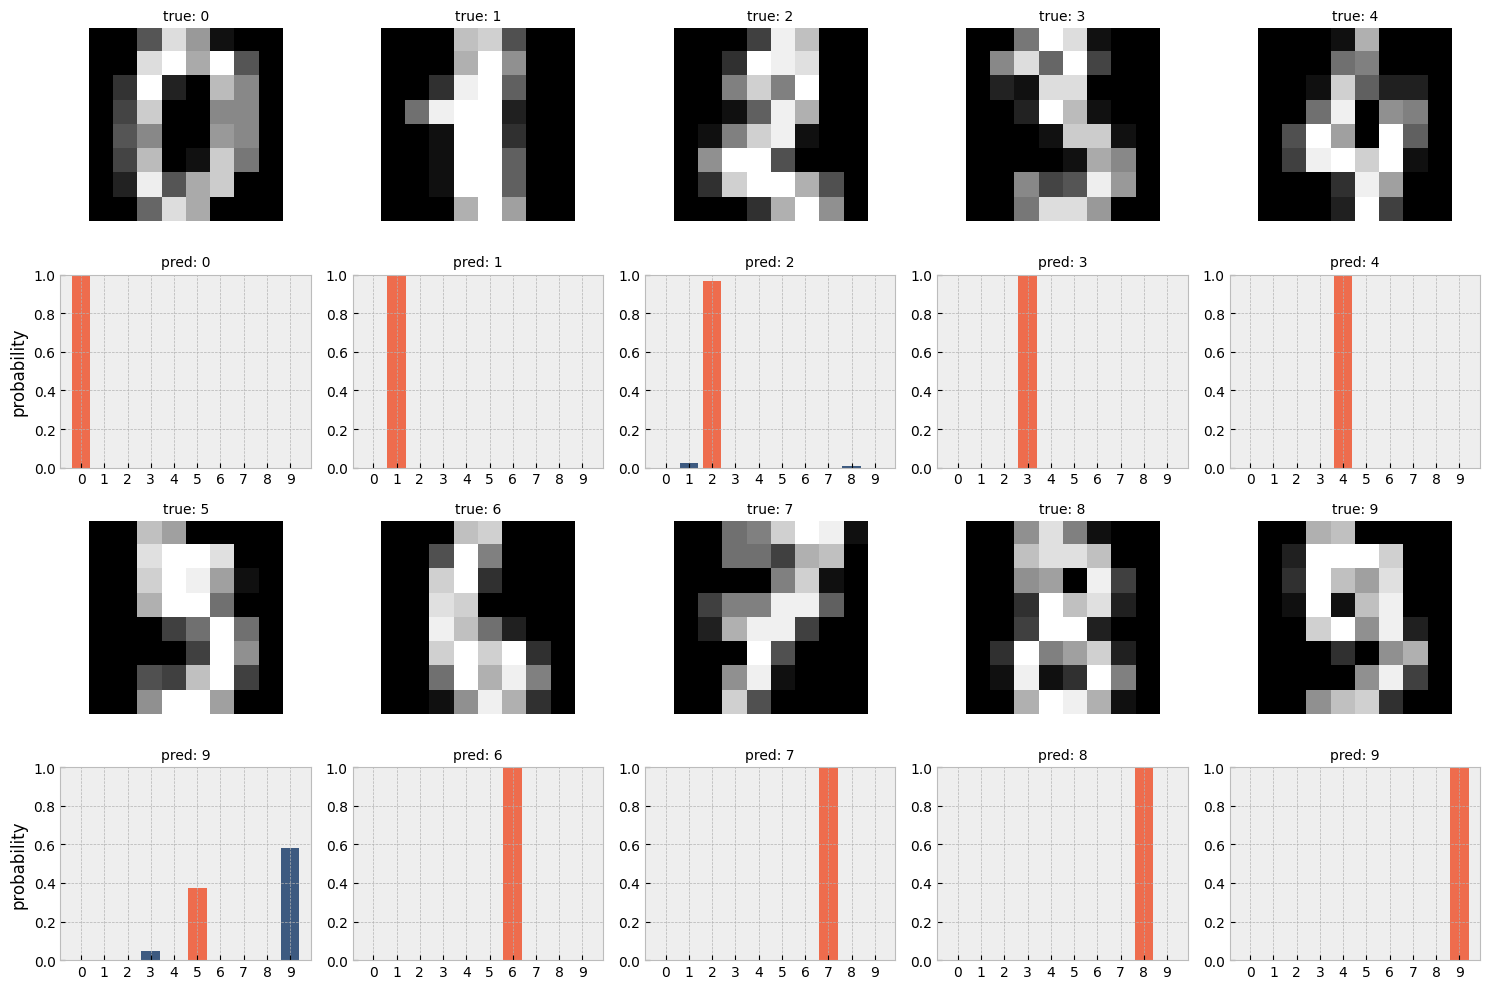

In [13]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('bmh') 
theme = ["#3d5a80","#98c1d9","#e0fbfc","#ee6c4d","#293241"]

fig, axes = plt.subplots(4, 5, figsize=(15, 10))

for i in range(10):
    # --- forward pass + softmax (your existing logic) ---
    logits = model(Tensor(reshaped_data[i])).data
    shifted = logits - np.max(logits)
    exps = np.exp(shifted)
    probs = exps / np.sum(exps)
    probs = probs.flatten()  # in case logits come out as (1, 10)

    true_label = digits.target[i]
    pred_label = np.argmax(probs)

    # Map i -> (row pair, col): images 0-4 -> rows 0/1, images 5-9 -> rows 2/3
    row_offset = (i // 5) * 2
    col = i % 5

    # --- image ---
    ax_img = axes[row_offset, col]
    ax_img.imshow(reshaped_data[i], cmap="gray")
    ax_img.set_title(f"true: {true_label}", fontsize=10)
    ax_img.axis("off")

    # --- probability distribution ---
    ax_bar = axes[row_offset + 1, col]
    colors = [theme[3] if j == true_label else theme[0] for j in range(10)]
    ax_bar.bar(range(10), probs, color=colors)
    ax_bar.set_xticks(range(10))
    ax_bar.set_ylim(0, 1)
    ax_bar.set_title(f"pred: {pred_label}", fontsize=10)
    if col == 0:
        ax_bar.set_ylabel("probability")

plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()